<a href="https://colab.research.google.com/github/phongsitt9/motor-glm-pricing/blob/main/04_glm_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
import os
warnings.filterwarnings("ignore")

df = pd.read_csv("clean_data.csv")

# แปลง categorical variables
for col in ["Area", "VehBrand", "VehGas", "Region"]:
    df[col] = df[col].astype("category")

In [3]:
# Fit Poisson GLM สำหรับ claim frequency
freq_model = smf.glm(
    formula="ClaimNb ~ Area + VehPower + VehAge + DrivAge + BonusMalus + VehGas",
    data=df,
    family=sm.families.Poisson(link=sm.families.links.Log()),
    offset=np.log(df["Exposure"])
).fit()

print(freq_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               163479
Model:                            GLM   Df Residuals:                   163468
Model Family:                 Poisson   Df Model:                           10
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -62825.
Date:                Mon, 25 May 2026   Deviance:                       90697.
Time:                        15:11:48   Pearson chi2:                 5.93e+05
No. Iterations:                     7   Pseudo R-squ. (CS):            0.03255
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -3.1946    

In [4]:
# ใช้เฉพาะ rows ที่มี claim เท่านั้น
df_claims = df[df["ClaimAmount"] > 0].copy()

# Fit Gamma GLM สำหรับ claim severity
sev_model = smf.glm(
    formula="ClaimAmount ~ Area + VehPower + VehAge + DrivAge + BonusMalus + VehGas",
    data=df_claims,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

print(sev_model.summary())
print(f"\n✅ Severity model fitted on {len(df_claims):,} claims")

                 Generalized Linear Model Regression Results                  
Dep. Variable:            ClaimAmount   No. Observations:                 8093
Model:                            GLM   Df Residuals:                     8082
Model Family:                   Gamma   Df Model:                           10
Link Function:                    Log   Scale:                          47.923
Method:                          IRLS   Log-Likelihood:                -87135.
Date:                Mon, 25 May 2026   Deviance:                       15076.
Time:                        15:12:21   Pearson chi2:                 3.87e+05
No. Iterations:                   100   Pseudo R-squ. (CS):           0.006920
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               6.6648    

In [5]:
# Predict frequency และ severity
df["PredFreq"] = freq_model.predict(df)
df["PredSev"]  = sev_model.predict(df)

# Pure Premium = Frequency × Severity
df["PredPurePremium"] = df["PredFreq"] * df["PredSev"]

print("=== Predicted vs Actual ===")
print(f"Mean actual pure premium:    EUR {df['PurePremium'].mean():.2f}")
print(f"Mean predicted pure premium: EUR {df['PredPurePremium'].mean():.2f}")

=== Predicted vs Actual ===
Mean actual pure premium:    EUR 582.71
Mean predicted pure premium: EUR 493.65


In [8]:
# Rate relativity = exp(coefficient)
# baseline คือ Area A, VehGas Regular

freq_params = freq_model.params
sev_params  = sev_model.params

# เอาเฉพาะ Area coefficients
area_cols = [c for c in freq_params.index if "Area" in c]

relativity = pd.DataFrame({
    "Factor":         ["Area[T.A] (baseline)"] + area_cols,
    "Freq_Coef":      [0.0] + [freq_params[c] for c in area_cols],
    "Sev_Coef":       [0.0] + [sev_params.get(c, 0) for c in area_cols],
})

relativity["Freq_Relativity"] = np.exp(relativity["Freq_Coef"]).round(4)
relativity["Sev_Relativity"]  = np.exp(relativity["Sev_Coef"]).round(4)
relativity["Combined"]        = (relativity["Freq_Relativity"] *
                                  relativity["Sev_Relativity"]).round(4)

display(relativity)
os.makedirs('outputs', exist_ok=True)
relativity.to_csv("outputs/rate_relativities.csv", index=False)
print("\n✅ Rate relativities saved")

,Factor,Freq_Coef,Sev_Coef,Freq_Relativity,Sev_Relativity,Combined
0,Area[T.A] (baseline),0.000000,0.000000,1.0000,1.0000,1.0000
1,Area[T.B],0.013716,0.328160,1.0138,1.3884,1.4076
2,Area[T.C],0.007607,-0.052881,1.0076,0.9485,0.9557
3,Area[T.D],0.054483,-0.404086,1.0560,0.6676,0.7050
4,Area[T.E],0.184427,-0.343303,1.2025,0.7094,0.8531
5,Area[T.F],0.311017,-0.879590,1.3648,0.4150,0.5664



✅ Rate relativities saved


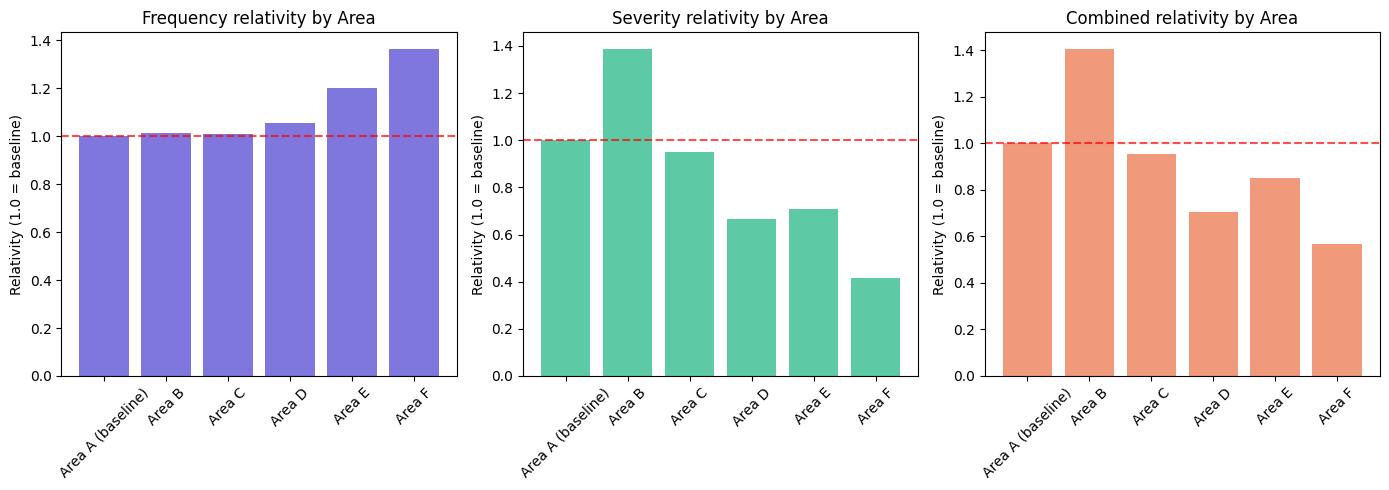


💡 Relativity > 1.0 = riskier than baseline → charge more premium


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

labels = relativity["Factor"].str.replace("Area[T.", "Area ").str.replace("]", "")

axes[0].bar(labels, relativity["Freq_Relativity"], color="#7F77DD")
axes[0].axhline(y=1.0, color="red", linestyle="--", alpha=0.7)
axes[0].set_title("Frequency relativity by Area")
axes[0].set_ylabel("Relativity (1.0 = baseline)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(labels, relativity["Sev_Relativity"], color="#5DCAA5")
axes[1].axhline(y=1.0, color="red", linestyle="--", alpha=0.7)
axes[1].set_title("Severity relativity by Area")
axes[1].set_ylabel("Relativity (1.0 = baseline)")
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(labels, relativity["Combined"], color="#F0997B")
axes[2].axhline(y=1.0, color="red", linestyle="--", alpha=0.7)
axes[2].set_title("Combined relativity by Area")
axes[2].set_ylabel("Relativity (1.0 = baseline)")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("outputs/rate_relativities_chart.png", dpi=150)
plt.show()
print("\n💡 Relativity > 1.0 = riskier than baseline → charge more premium")

In [11]:
import pandas as pd

# Ensure predictions are present before summary
df["PredFreq"] = freq_model.predict(df)
df["PredSev"]  = sev_model.predict(df)
df["PredPurePremium"] = df["PredFreq"] * df["PredSev"]

summary = pd.DataFrame({
    "Metric": [
        "Frequency model AIC",
        "Severity model AIC",
        "Frequency model deviance",
        "Severity model deviance",
        "Policies predicted",
        "Mean predicted pure premium (EUR)"
    ],
    "Value": [
        f"{freq_model.aic:,.0f}",
        f"{sev_model.aic:,.0f}",
        f"{freq_model.deviance:,.0f}",
        f"{sev_model.deviance:,.0f}",
        f"{len(df):,}",
        f"{df['PredPurePremium'].mean():.2f}"
    ]
})

display(summary)
summary.to_csv("outputs/model_summary.csv", index=False)
print("\n✅ Notebook 04 complete — ready for Notebook 05")

,Metric,Value
0,Frequency model AIC,"125,671"
1,Severity model AIC,"174,293"
2,Frequency model deviance,"90,697"
3,Severity model deviance,"15,076"
4,Policies predicted,"678,013"
5,Mean predicted pure premium (EUR),505.19



✅ Notebook 04 complete — ready for Notebook 05
